# Fourier Methods for European Option Pricing

**Columbia University · MAFN · MATH 5030 · Spring 2026**  
Submission notebook for project defense and review  
Engine: `foureng`  
Instructor: Prof. Jaehyuk Choi

This notebook is organized as a validation-first story for European option pricing:

1. Anchor one benchmark contract and one timing/error protocol.
2. Show why Fourier methods matter relative to Monte Carlo.
3. Stress-test Carr-Madan and Lewis through their numerical parameters.
4. Gate COS on published-style benchmarks before making speed claims.
5. Show how Junike-style truncation improves support selection without changing the pricing formula.
6. Finish with a cross-model diagnostic scan.

## Validation-first workflow

The notebook follows the same pipeline used in the codebase:

$$
\text{Characteristic function}
\;\longrightarrow\;
\text{Fourier pricer}
\;\longrightarrow\;
\text{implied-vol inversion}
\;\longrightarrow\;
\text{validation}
\;\longrightarrow\;
\text{benchmarking}
$$

The reporting rules are simple:

- **Shared error metric:** max absolute error against a trusted reference.
- **Shared timing metric:** median wall time across repeated runs.
- **Shared policy:** benchmarking claims only count after the validation gates are green.

In [1]:
# ── Run configuration ──────────────────────────────────────────────────
# Change these and re-run from here; every section reads them.
METHOD            = "cos"                         # "cos" | "carr_madan" | "lewis" | "cos_junike"
N_BENCH           = 256                             # default COS resolution
MC_PATHS          = [1_000, 10_000, 100_000, 1_000_000]
FFT_N             = 4096                            # default Carr-Madan grid
SEED              = 42

# ── Imports ────────────────────────────────────────────────────────────
import pathlib
import sys
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import norm

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore", category=RuntimeWarning)

CWD = pathlib.Path.cwd().resolve()
for candidate in (CWD, *CWD.parents):
    if (candidate / "foureng").exists() and (candidate / "benchmarks").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError(f"Could not locate repo root from {CWD}")

for path in (REPO_ROOT,):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from foureng.models.base import ForwardSpec
from foureng.models.bsm import BsmParams, bsm_cf, bsm_cumulants
from foureng.models.heston import HestonParams, heston_cf_form2, heston_cumulants
from foureng.models.variance_gamma import VGParams, vg_cf, vg_cumulants
from foureng.models.cgmy import CgmyParams, cgmy_cf, cgmy_cumulants
from foureng.models.kou import KouParams, kou_cf, kou_cumulants
from foureng.models.nig import NigParams, nig_cf, nig_cumulants
from foureng.models.ousv import OusvParams, ousv_cf, ousv_cumulants
from foureng.models.bates import BatesParams, bates_cf, bates_cumulants
from foureng.models.heston_kou import HestonKouParams, heston_kou_cf, heston_kou_cumulants
from foureng.models.heston_cgmy import HestonCGMYParams, heston_cgmy_cf, heston_cgmy_cumulants

from foureng.pricers.cos import cos_prices, cos_auto_grid, cos_improved_grid
from foureng.pricers.carr_madan import carr_madan_price_at_strikes
from foureng.pricers.lewis import lewis_call_prices
from foureng.utils.grids import FFTGrid
from foureng.mc.black_scholes_mc import european_call_mc, MCSpec
from foureng.viz import (
    apply_columbia_style,
    NAVY,
    COLUMBIA_BLUE,
    DARK,
    SLATE,
    ORANGE,
    GREEN,
    PANEL,
    CLOUD,
)

apply_columbia_style()
CU_BLUE = NAVY
CU_LIGHT = COLUMBIA_BLUE
CU_ACC = CLOUD
CU_ORANGE = ORANGE
CU_GREEN = GREEN
CU_GREY = SLATE
CU_BG = PANEL
IMG_DIR = REPO_ROOT / "images"

print(f"config:  METHOD={METHOD!r}  N_BENCH={N_BENCH}  FFT_N={FFT_N}  seed={SEED}")
print(f"libs OK. numpy={np.__version__}")
print(f"repo root: {REPO_ROOT}")

config:  METHOD='cos'  N_BENCH=256  FFT_N=4096  seed=42
libs OK. numpy=2.4.4
repo root: /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5030/Project/5030_Carr-Madan


In [2]:
# ── Helpers: analytic BS reference, method-dispatch pricer, timing, tables ──

def bs_call(S0, K, T, r, q, sigma):
    K = np.asarray(K, dtype=float)
    d1 = (np.log(S0/K) + (r - q + 0.5*sigma*sigma)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


def timed(fn, repeats=5):
    """Return (last_value, median_wall_ms)."""
    ts = []
    val = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        val = fn()
        ts.append((time.perf_counter() - t0) * 1e3)
    return val, float(np.median(ts))


def price_with(method, *, phi, fwd, strikes, cums, N, model=None, params=None,
               fft_n=None, alpha=1.5, eta_fft=0.25,
               u_max=200.0, n_u=4_096):
    """Method-dispatched pricer."""
    if method == "cos":
        grid = cos_auto_grid(cums, N=N, L=10.0)
        return cos_prices(phi, fwd, strikes, grid).call_prices
    if method == "cos_junike":
        grid = cos_improved_grid(cums, model=model, params=params)
        return cos_prices(phi, fwd, strikes, grid).call_prices
    if method == "carr_madan":
        return carr_madan_price_at_strikes(phi, fwd,
            FFTGrid(N=int(fft_n or FFT_N), eta=eta_fft, alpha=alpha), strikes)
    if method == "lewis":
        return lewis_call_prices(phi, strikes, fwd.S0, fwd.T,
                                 intr=fwd.r, divr=fwd.q, is_fwd=False,
                                 u_max=u_max, n_u=n_u)
    raise ValueError(f"unknown method {method!r}")


# ── Columbia-styled pandas tables ──────────────────────────────────────
# Readable zebra: strong enough to see, light enough to print.

def style_table(df, caption, *, gradient_cols=None, highlight_col=None):
    """Return a pandas Styler with Columbia colours and a readable zebra."""
    styler = (df.style
                .format(precision=4, thousands=",")
                .set_caption(caption)
                .set_table_styles([
                    {"selector":"caption",
                     "props":[("color",CU_BLUE),("font-weight","700"),
                              ("font-size","13.5px"),("padding","4px 0 10px 0"),
                              ("text-align","left"),("caption-side","top")]},
                    {"selector":"table",
                     "props":[("border-collapse","separate"),("border-spacing","0"),
                              ("margin","4px 0 10px 0"),("width","auto"),
                              ("font-size","12.5px"),("color","#1a2230"),
                              ("border","1px solid #CAD4E3"),("border-radius","6px"),
                              ("overflow","hidden")]},
                    {"selector":"thead th",
                     "props":[("background",CU_BLUE),("color","white"),
                              ("font-weight","700"),("padding","8px 12px"),
                              ("border","none"),("text-align","center")]},
                    {"selector":"tbody th",
                     "props":[("background","white"),("color",CU_BLUE),
                              ("font-weight","700"),("padding","6px 10px"),
                              ("border-right","2px solid #012169"),
                              ("border-bottom","1px solid #E1E7EF"),
                              ("text-align","left")]},
                    {"selector":"tbody td",
                     "props":[("padding","6px 12px"),
                              ("border-bottom","1px solid #E1E7EF"),
                              ("color","#1a2230")]},
                    {"selector":"tbody tr:nth-child(odd)  td",
                     "props":[("background","#FFFFFF")]},
                    {"selector":"tbody tr:nth-child(even) td",
                     "props":[("background","#EAF0F8")]},
                    {"selector":"tbody tr:nth-child(odd)  th",
                     "props":[("background","#FFFFFF")]},
                    {"selector":"tbody tr:nth-child(even) th",
                     "props":[("background","#EAF0F8")]},
                    {"selector":"tbody tr:hover td",
                     "props":[("background","#D6E2F2")]},
                ]))
    if gradient_cols:
        styler = styler.background_gradient(
            cmap="Blues", subset=gradient_cols, axis=None, low=0.02, high=0.85
        )
    if highlight_col:
        styler = styler.apply(lambda s: ["font-weight:700;color:#012169" if c==highlight_col else ""
                                         for c in s.index], axis=0)
    return styler


print("helpers ready.")

helpers ready.


## 1. Problem setup and common benchmark

One contract, one model, one truth value, one timing protocol.

For Black-Scholes the analytic call price is the reference:

$$
C_{\mathrm{BS}} = S_0 e^{-qT} N(d_1) - K e^{-rT} N(d_2),
$$

with

$$
d_1 = \frac{\log(S_0/K) + (r-q+\tfrac12 \sigma^2)T}{\sigma\sqrt{T}},
\qquad
d_2 = d_1 - \sigma\sqrt{T}.
$$

Shared contract:

- $S_0 = 100$
- $K = 100$
- $T = 0.5$
- $r = 5\%$
- $q = 0$
- $\sigma = 20\%$
- Error metric: $|\hat C - C_{\mathrm{BS}}|$
- Runtime metric: median wall time in milliseconds

In [3]:
# Shared problem setup
S0, r, q, T, sigma = 100.0, 0.05, 0.0, 0.5, 0.20
K_scalar   = 100.0
K          = np.array([K_scalar])
fwd_bsm    = ForwardSpec(S0=S0, r=r, q=q, T=T)
p_bsm      = BsmParams(sigma=sigma)
phi_bsm    = lambda u: bsm_cf(u, fwd_bsm, p_bsm)
cums_bsm   = bsm_cumulants(fwd_bsm, p_bsm)

C_REF = float(bs_call(S0, K, T, r, q, sigma)[0])

df0 = pd.DataFrame({
    "quantity":  ["S0", "K", "T", "r", "q", "sigma", "analytic call C_BS"],
    "value":     [S0, K_scalar, T, r, q, sigma, C_REF],
})
display(style_table(df0, "Common benchmark — every later section prices against this truth"))

,quantity,value
0,S0,100.0000
1,K,100.0000
2,T,0.5000
3,r,0.0500
4,q,0.0000
5,sigma,0.2000
6,analytic call C_BS,6.8887


## 2. Monte Carlo baseline vs Carr-Madan

Monte Carlo is the flexible baseline. Carr-Madan is the first deterministic
Fourier benchmark.

The key asymptotic fact for Monte Carlo is

$$
\varepsilon_{\mathrm{MC}} = O(n^{-1/2}),
$$

so reducing error by one order of magnitude requires roughly two orders of
magnitude more paths.

What we compare below:

- Monte Carlo error as the path count increases.
- Carr-Madan error as the FFT grid size increases.
- Runtime vs error on the same Black-Scholes contract.

In [4]:
# 2 — MC vs Carr-Madan on the shared BSM call
rows = []

# Monte Carlo sweep
for n in MC_PATHS:
    v, ms = timed(lambda n=n: float(european_call_mc(S0, K, T, r, q, sigma,
                                                     MCSpec(n_paths=int(n), seed=SEED))[0]),
                  repeats=3)
    rows.append({"engine":"Monte Carlo", "knob":"paths", "N":int(n),
                 "price":v, "|err|":abs(v-C_REF), "ms":ms})

# Carr-Madan FFT sweep
for N in (256, 1024, 4096, 16384):
    v, ms = timed(lambda N=N: float(carr_madan_price_at_strikes(
                       phi_bsm, fwd_bsm, FFTGrid(N=N, eta=0.25, alpha=1.5), K)[0]),
                  repeats=5)
    rows.append({"engine":"Carr-Madan", "knob":"FFT N", "N":N,
                 "price":v, "|err|":abs(v-C_REF), "ms":ms})

df2 = pd.DataFrame(rows)
df2_fmt = df2.assign(**{"|err|": df2["|err|"].map(lambda v: f"{v:.2e}"),
                        "price": df2["price"].map(lambda v: f"{v:.6f}"),
                        "ms":    df2["ms"].map(lambda v: f"{v:.2f}")})
display(style_table(df2_fmt, f"MC sample sweep vs Carr-Madan FFT grid sweep · analytic ref = {C_REF:.8f}"))

,engine,knob,N,price,|err|,ms
0,Monte Carlo,paths,"1,000",6.526724,3.62e-01,0.31
1,Monte Carlo,paths,"10,000",6.815729,7.30e-02,0.24
2,Monte Carlo,paths,"100,000",6.867289,2.14e-02,1.93
3,Monte Carlo,paths,"1,000,000",6.890351,1.62e-03,23.93
4,Carr-Madan,FFT N,256,6.890242,1.51e-03,0.24
5,Carr-Madan,FFT N,"1,024",6.888728,2.32e-07,0.34
6,Carr-Madan,FFT N,"4,096",6.888728,2.14e-07,0.92
7,Carr-Madan,FFT N,"16,384",6.888728,2.17e-07,3.35


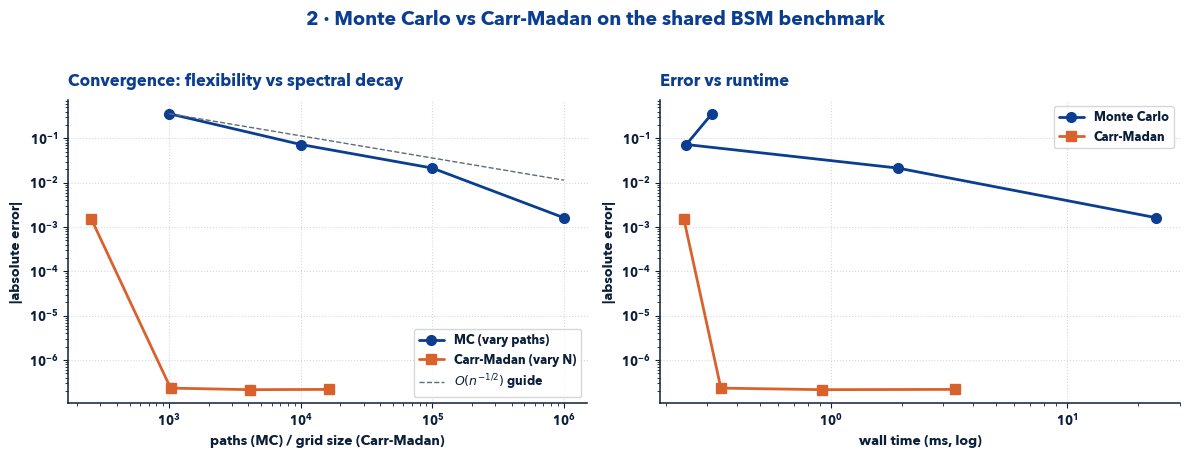

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

mc = df2[df2["engine"]=="Monte Carlo"]
cm = df2[df2["engine"]=="Carr-Madan"]

# Panel A — error vs knob
ax[0].loglog(mc["N"], mc["|err|"], "o-", color=CU_BLUE,   lw=2, ms=7, label="MC (vary paths)")
ax[0].loglog(cm["N"], cm["|err|"], "s-", color=CU_ORANGE, lw=2, ms=7, label="Carr-Madan (vary N)")
guide = mc["|err|"].iloc[0] * (mc["N"].iloc[0]/mc["N"])**0.5
ax[0].loglog(mc["N"], guide, "--", color=CU_GREY, lw=1, label=r"$O(n^{-1/2})$ guide")
ax[0].set_xlabel("paths (MC) / grid size (Carr-Madan)")
ax[0].set_ylabel("|absolute error|")
ax[0].set_title("Convergence: flexibility vs spectral decay")
ax[0].legend()

# Panel B — error vs runtime (the economic comparison)
ax[1].loglog(mc["ms"], mc["|err|"], "o-", color=CU_BLUE,   lw=2, ms=7, label="Monte Carlo")
ax[1].loglog(cm["ms"], cm["|err|"], "s-", color=CU_ORANGE, lw=2, ms=7, label="Carr-Madan")
ax[1].set_xlabel("wall time (ms, log)")
ax[1].set_ylabel("|absolute error|")
ax[1].set_title("Error vs runtime")
ax[1].legend()

plt.suptitle("2 · Monte Carlo vs Carr-Madan on the shared BSM benchmark",
             color=CU_BLUE, fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 3. Carr-Madan vs Lewis FFT: parameter sensitivity

Both methods read the same characteristic function and target the same price.
The main question is numerical sensitivity:

- Carr-Madan depends on damping $\alpha$ and grid spacing $\eta$.
- Lewis depends on integration cutoff $u_{\max}$ and node count $n_u$.

The experiment below uses the same BSM contract as Section 1 and sweeps each
method across a practical parameter grid. A stable numerical regime should look
like a broad low-error plateau rather than a single lucky point.

In [6]:
# 3 — Parameter-sensitivity sweeps for Carr-Madan and Lewis

# Carr-Madan: vary alpha (damping) x eta (grid)
alphas = [1.0, 1.25, 1.5, 2.0, 3.0]
etas   = [0.05, 0.1, 0.25, 0.5, 1.0]
grid_cm = np.full((len(alphas), len(etas)), np.nan)
for i, a in enumerate(alphas):
    for j, e in enumerate(etas):
        try:
            v = carr_madan_price_at_strikes(phi_bsm, fwd_bsm,
                    FFTGrid(N=FFT_N, eta=e, alpha=a), K)[0]
            grid_cm[i, j] = abs(v - C_REF)
        except Exception:
            pass

df_cm_sens = pd.DataFrame(grid_cm, index=[f"alpha={a}" for a in alphas],
                          columns=[f"eta={e}" for e in etas])
df_cm_sens_fmt = df_cm_sens.apply(lambda col: col.map(lambda v: "nan" if np.isnan(v) else f"{v:.2e}"))
display(style_table(df_cm_sens_fmt,
                    "Carr-Madan · |error| across (alpha, eta) — wants a flat plateau"))

# Lewis: vary u_max x n_u
umaxes = [50, 100, 200, 400, 800]
nus    = [1024, 2048, 4096, 8192, 16384]
grid_lw = np.full((len(umaxes), len(nus)), np.nan)
for i, um in enumerate(umaxes):
    for j, nu in enumerate(nus):
        try:
            v = lewis_call_prices(phi_bsm, K, fwd_bsm.S0, fwd_bsm.T,
                                  intr=fwd_bsm.r, divr=fwd_bsm.q,
                                  is_fwd=False, u_max=float(um), n_u=int(nu))[0]
            grid_lw[i, j] = abs(v - C_REF)
        except Exception:
            pass
df_lw_sens = pd.DataFrame(grid_lw, index=[f"u_max={u}" for u in umaxes],
                          columns=[f"n_u={n}" for n in nus])
df_lw_sens_fmt = df_lw_sens.apply(lambda col: col.map(lambda v: "nan" if np.isnan(v) else f"{v:.2e}"))
display(style_table(df_lw_sens_fmt,
                    "Lewis FFT · |error| across (u_max, n_u)"))

,eta=0.05,eta=0.1,eta=0.25,eta=0.5,eta=1.0
alpha=1.0,1.23e-05,1.58e-06,1.16e-04,6.18e-02,1.20e+00
alpha=1.25,1.23e-05,1.58e-06,5.02e-06,1.29e-02,5.91e-01
alpha=1.5,1.23e-05,1.58e-06,2.14e-07,2.68e-03,2.79e-01
alpha=2.0,1.23e-05,1.58e-06,2.71e-09,1.16e-04,5.93e-02
alpha=3.0,1.23e-05,1.58e-06,3.12e-09,2.16e-07,2.58e-03


,n_u=1024,n_u=2048,n_u=4096,n_u=8192,n_u=16384
u_max=50,5.77e-14,4.44e-14,4.44e-14,3.02e-14,5.77e-14
u_max=100,2.10e-12,1.69e-14,2.66e-15,2.66e-15,1.15e-14
u_max=200,2.04e-05,2.10e-12,1.69e-14,2.66e-15,2.66e-15
u_max=400,6.35e-02,2.04e-05,2.10e-12,1.69e-14,2.66e-15
u_max=800,3.61e+00,6.35e-02,2.04e-05,2.10e-12,1.69e-14


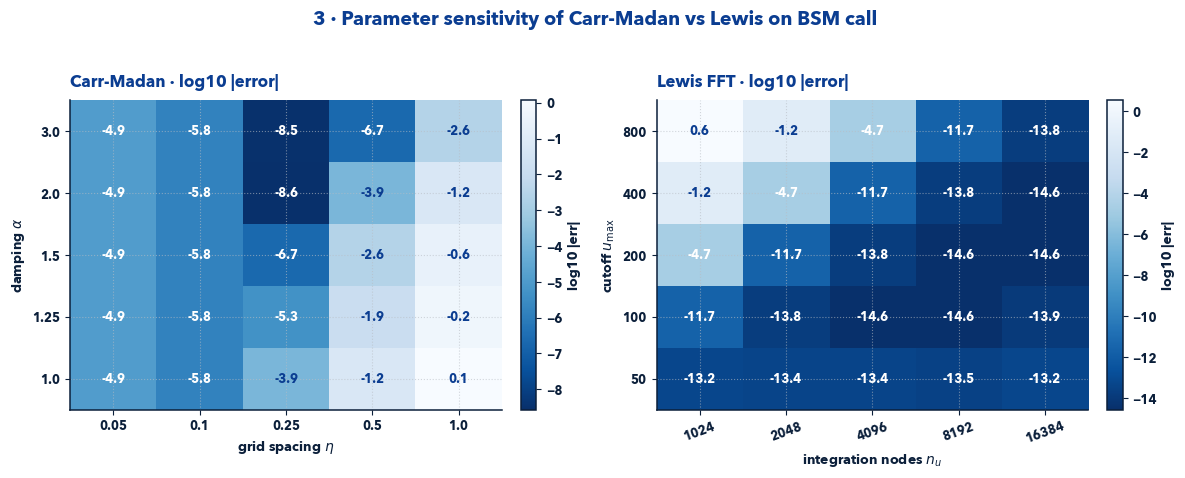

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))

im0 = ax[0].imshow(np.log10(grid_cm), aspect="auto", cmap="Blues_r",
                   origin="lower")
ax[0].set_xticks(range(len(etas)));   ax[0].set_xticklabels([f"{e}" for e in etas])
ax[0].set_yticks(range(len(alphas))); ax[0].set_yticklabels([f"{a}" for a in alphas])
ax[0].set_xlabel(r"grid spacing $\eta$")
ax[0].set_ylabel(r"damping $\alpha$")
ax[0].set_title("Carr-Madan · log10 |error|")
for i in range(grid_cm.shape[0]):
    for j in range(grid_cm.shape[1]):
        if not np.isnan(grid_cm[i,j]):
            ax[0].text(j, i, f"{np.log10(grid_cm[i,j]):.1f}",
                       ha="center", va="center", fontsize=9,
                       color="white" if np.log10(grid_cm[i,j]) < -4 else CU_BLUE)
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04, label="log10 |err|")

im1 = ax[1].imshow(np.log10(grid_lw), aspect="auto", cmap="Blues_r",
                   origin="lower")
ax[1].set_xticks(range(len(nus)));    ax[1].set_xticklabels([f"{n}" for n in nus], rotation=20)
ax[1].set_yticks(range(len(umaxes))); ax[1].set_yticklabels([f"{u}" for u in umaxes])
ax[1].set_xlabel("integration nodes $n_u$")
ax[1].set_ylabel(r"cutoff $u_\mathrm{max}$")
ax[1].set_title("Lewis FFT · log10 |error|")
for i in range(grid_lw.shape[0]):
    for j in range(grid_lw.shape[1]):
        if not np.isnan(grid_lw[i,j]):
            ax[1].text(j, i, f"{np.log10(grid_lw[i,j]):.1f}",
                       ha="center", va="center", fontsize=9,
                       color="white" if np.log10(grid_lw[i,j]) < -4 else CU_BLUE)
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04, label="log10 |err|")

plt.suptitle("3 · Parameter sensitivity of Carr-Madan vs Lewis on BSM call",
             color=CU_BLUE, fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 4. Plain COS (Fang-Oosterlee 2008)

This section uses the classical COS setup:

$$
[a,b] = \left[c_1 - L\sqrt{c_2 + \sqrt{|c_4|}},\;
              c_1 + L\sqrt{c_2 + \sqrt{|c_4|}}\right],
\qquad L = 10.
$$

The COS pricing formula can be written as

$$
C(K) = e^{-rT} \sum_{k=0}^{N-1}{}'
\operatorname{Re}\!\left[
\phi\!\left(\frac{k\pi}{b-a}\right)
e^{-ik\pi a/(b-a)}
\right] V_k.
$$

For smooth densities such as Black-Scholes, the expected behavior is spectral
convergence: large error reduction as $N$ doubles.

In [8]:
# 4 — Plain COS on the shared BSM contract
rows4 = []
for N in (16, 32, 64, 96, 128, 192, 256):
    (price,), ms = timed(lambda N=N: cos_prices(phi_bsm, fwd_bsm, K,
                            cos_auto_grid(cums_bsm, N=N, L=10.0)).call_prices,
                         repeats=5)
    rows4.append({"N":N, "price":float(price), "|err|":abs(float(price)-C_REF), "ms":ms})

df4 = pd.DataFrame(rows4)
df4_fmt = df4.assign(**{"|err|": df4["|err|"].map(lambda v: f"{v:.2e}"),
                         "price":df4["price"].map(lambda v: f"{v:.10f}"),
                         "ms":   df4["ms"].map(lambda v: f"{v:.3f}")})
display(style_table(df4_fmt, f"Plain COS (FO2008, L=10) · analytic ref = {C_REF:.10f}"))

,N,price,|err|,ms
0,16,6.9005022594,1.18e-02,0.066
1,32,6.8887287275,1.50e-07,0.062
2,64,6.8887285777,8.88e-15,0.061
3,96,6.8887285777,8.88e-15,0.060
4,128,6.8887285777,8.88e-15,0.062
5,192,6.8887285777,8.88e-15,0.066
6,256,6.8887285777,8.88e-15,0.070


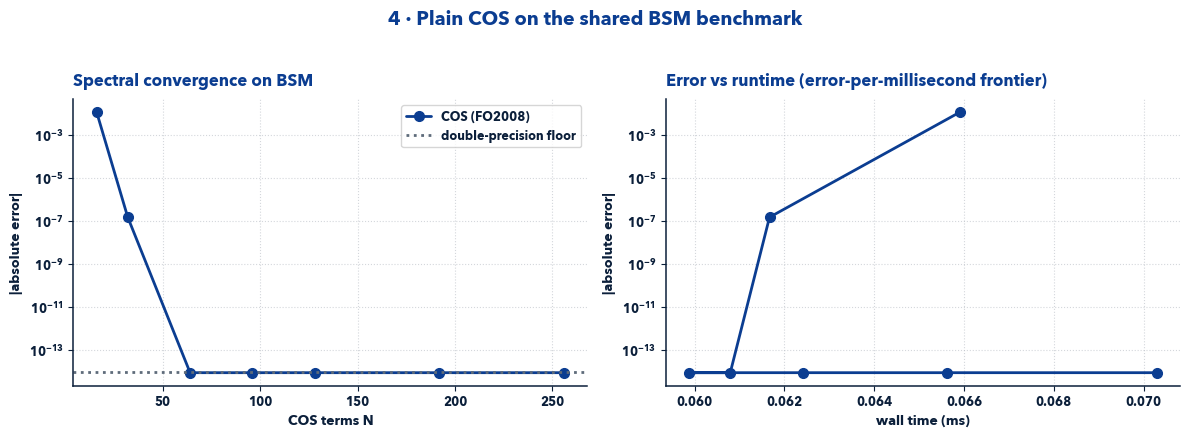

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

ax[0].semilogy(df4["N"], df4["|err|"], "o-", color=CU_BLUE, lw=2, ms=7, label="COS (FO2008)")
ax[0].axhline(1e-14, color=CU_GREY, ls=":", label="double-precision floor")
ax[0].set_xlabel("COS terms N")
ax[0].set_ylabel("|absolute error|")
ax[0].set_title("Spectral convergence on BSM")
ax[0].legend()

ax[1].semilogy(df4["ms"], df4["|err|"], "o-", color=CU_BLUE, lw=2, ms=7)
ax[1].set_xlabel("wall time (ms)")
ax[1].set_ylabel("|absolute error|")
ax[1].set_title("Error vs runtime (error-per-millisecond frontier)")

plt.suptitle("4 · Plain COS on the shared BSM benchmark",
             color=CU_BLUE, fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 5. COS with improved truncation

Junike's contribution is not a new pricer. It is a better interval-selection
policy around the same COS engine.

Instead of fixing the support from a cumulant multiplier, choose the half-width
$M$ from a tail tolerance:

$$
\mathbb{P}(|X-m| \ge M) \le \frac{\mathbb{E}[|X-m|^n]}{M^n}.
$$

This leads to the support choice

$$
[a,b] = [m-M,\; m+M],
\qquad
M \ge \left(\frac{\mathbb{E}[|X-m|^n]}{\varepsilon}\right)^{1/n}.
$$

Comparison protocol:

- Same pricing formula.
- Same underlying contract.
- Same model family.
- Only the support-selection policy changes.

The stress case below is CGMY with $Y=1.98$, where the classical cumulant rule
becomes fragile.

In [10]:
USE_JUNIKE_TRUNC = True   # method flag

# 5a — On the shared BSM benchmark the two rules should agree
rows_bsm = []
for label, grid_fn in (
    ("classical (FO2008 L=10)", lambda: cos_auto_grid(cums_bsm, N=N_BENCH, L=10.0)),
    ("improved (Junike-style)", lambda: cos_improved_grid(cums_bsm, model="bsm", params=p_bsm)),
):
    g = grid_fn()
    (price,), ms = timed(lambda g=g: cos_prices(phi_bsm, fwd_bsm, K, g).call_prices, repeats=5)
    rows_bsm.append({"truncation":label, "N":g.N, "a":g.a, "b":g.b,
                     "width":g.b-g.a, "price":float(price),
                     "|err|":abs(float(price)-C_REF), "ms":ms})
df5a = pd.DataFrame(rows_bsm)
display(style_table(df5a, "5a — BSM call · both rules should agree (smooth density)"))

# 5b — CGMY Y=1.98 stress case
fwd_c  = ForwardSpec(S0=100.0, r=0.1, q=0.0, T=1.0)
p_c    = CgmyParams(C=1.0, G=5.0, M=5.0, Y=1.98)
phi_c  = lambda u: cgmy_cf(u, fwd_c, p_c)
cums_c = cgmy_cumulants(fwd_c, p_c)
K_c    = np.array([100.0])

# reference: very wide Lewis integral
ref_c = float(lewis_call_prices(phi_c, K_c, fwd_c.S0, fwd_c.T,
                                intr=fwd_c.r, divr=fwd_c.q, is_fwd=False,
                                u_max=600.0, n_u=65_536)[0])

rows_cgmy = []
for label, grid_fn in (
    ("classical (FO2008 L=10)", lambda: cos_auto_grid(cums_c, N=N_BENCH, L=10.0)),
    ("improved (Junike-style)", lambda: cos_improved_grid(cums_c, model="cgmy", params=p_c)),
):
    g = grid_fn()
    (price,), ms = timed(lambda g=g: cos_prices(phi_c, fwd_c, K_c, g).call_prices, repeats=5)
    rows_cgmy.append({"truncation":label, "N":g.N, "a":g.a, "b":g.b,
                      "width":g.b-g.a, "price":float(price),
                      "|err|":abs(float(price)-ref_c), "ms":ms})
df5b = pd.DataFrame(rows_cgmy)
display(style_table(df5b,
    f"5b — CGMY Y=1.98 stress · Lewis reference = {ref_c:.8f}"))

,truncation,N,a,b,width,price,|err|,ms
0,classical (FO2008 L=10),256,-1.4242,1.4042,2.8284,6.8887,0.0000,0.0752
1,improved (Junike-style),128,-1.1314,1.1314,2.2627,6.8887,0.0000,0.0680


,truncation,N,a,b,width,price,|err|,ms
0,classical (FO2008 L=10),256,-145.8751,50.1164,195.9915,99.9999,0.0000,0.1022
1,improved (Junike-style),"8,192",-137.1940,137.1940,274.3881,99.9999,0.0000,2.1056


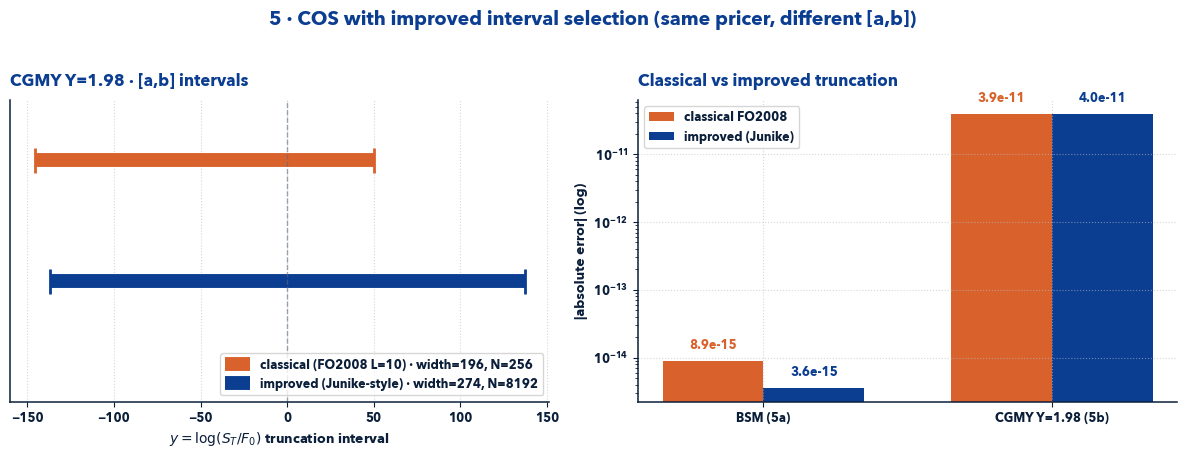

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

# Left: truncation intervals for CGMY
for i, row in df5b.reset_index(drop=True).iterrows():
    y = 1 - 0.4*i
    c = CU_ORANGE if i == 0 else CU_BLUE
    ax[0].hlines(y, row["a"], row["b"], color=c, lw=10,
                 label=f"{row['truncation']} · width={row['width']:.0f}, N={row['N']}")
    ax[0].plot([row["a"], row["b"]], [y, y], "|", ms=18, mew=2, color=c)
ax[0].axvline(0, color=CU_GREY, ls="--", lw=1, alpha=0.6)
ax[0].set_xlabel(r"$y = \log(S_T/F_0)$ truncation interval")
ax[0].set_ylim(0.2, 1.2)
ax[0].set_yticks([])
ax[0].set_title("CGMY Y=1.98 · [a,b] intervals")
ax[0].legend(loc="lower right", fontsize=9)

# Right: errors on both benchmarks, grouped
labels = ["BSM (5a)", "CGMY Y=1.98 (5b)"]
classical = [df5a.loc[0, "|err|"], df5b.loc[0, "|err|"]]
improved  = [df5a.loc[1, "|err|"], df5b.loc[1, "|err|"]]
x = np.arange(len(labels))
w = 0.35
ax[1].bar(x-w/2, np.clip(classical, 1e-16, None), w,
          color=CU_ORANGE, label="classical FO2008")
ax[1].bar(x+w/2, np.clip(improved,  1e-16, None), w,
          color=CU_BLUE,   label="improved (Junike)")
for i, (c, im) in enumerate(zip(classical, improved)):
    ax[1].text(i-w/2, max(c, 1e-16)*1.5, f"{c:.1e}", ha="center", fontsize=9, color=CU_ORANGE)
    ax[1].text(i+w/2, max(im,1e-16)*1.5, f"{im:.1e}", ha="center", fontsize=9, color=CU_BLUE)
ax[1].set_yscale("log")
ax[1].set_xticks(x); ax[1].set_xticklabels(labels)
ax[1].set_ylabel("|absolute error| (log)")
ax[1].set_title("Classical vs improved truncation")
ax[1].legend()

plt.suptitle("5 · COS with improved interval selection (same pricer, different [a,b])",
             color=CU_BLUE, fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 6. Multi-model sweep and cross-model diagnostics

The final scan asks a practical question: at a fixed compute budget, where does
one Fourier engine clearly underperform another?

Model families in the scan:

- **Pure diffusion:** BSM
- **Stochastic volatility:** Heston, OUSV
- **Pure jump / Lévy:** VG, CGMY, NIG
- **Jump diffusion:** Kou
- **SV + jumps:** Bates, Heston-Kou, Heston-CGMY

A row is flagged as an anomaly when

$$
\frac{\text{worst error}}{\text{best error}} > 10
\quad\text{and}\quad
\text{worst error} > 10^{-4}.
$$

These flags are diagnostics, not notebook-side patches.

In [12]:
# 6 — Cross-model diagnostics
scan_cases = [
    # (label, family, fwd, params, cf_fn, cum_fn, model_key)
    ("BSM",          "Pure diffusion",
        ForwardSpec(S0=100,r=0.05,q=0,T=0.5), BsmParams(sigma=0.20),
        bsm_cf, bsm_cumulants, "bsm"),
    ("Heston T=1",   "Stochastic vol",
        ForwardSpec(S0=100,r=0.0,q=0,T=1.0),
        HestonParams(kappa=1.5768, theta=0.0398, nu=0.5751, rho=-0.5711, v0=0.0175),
        heston_cf_form2, heston_cumulants, "heston"),
    ("OUSV",         "Stochastic vol",
        ForwardSpec(S0=100,r=0.05,q=0,T=1.0),
        OusvParams(sigma0=0.2, kappa=1.0, theta=0.2, nu=0.3, rho=-0.5),
        ousv_cf, ousv_cumulants, "ousv"),
    ("VG",           "Pure jump / Levy",
        ForwardSpec(S0=100,r=0.1,q=0,T=1.0),
        VGParams(sigma=0.12,nu=0.2,theta=-0.14),
        vg_cf, vg_cumulants, "vg"),
    ("CGMY Y=0.5",   "Pure jump / Levy",
        ForwardSpec(S0=100,r=0.1,q=0,T=1.0),
        CgmyParams(C=1,G=5,M=5,Y=0.5),
        cgmy_cf, cgmy_cumulants, "cgmy"),
    ("CGMY Y=1.5",   "Pure jump / Levy",
        ForwardSpec(S0=100,r=0.1,q=0,T=1.0),
        CgmyParams(C=1,G=5,M=5,Y=1.5),
        cgmy_cf, cgmy_cumulants, "cgmy"),
    ("NIG",          "Pure jump / Levy",
        ForwardSpec(S0=100,r=0.05,q=0,T=0.5),
        NigParams(sigma=0.2, nu=0.5, theta=-0.1),
        nig_cf, nig_cumulants, "nig"),
    ("Kou",          "Jump diffusion",
        ForwardSpec(S0=100,r=0.05,q=0,T=0.5),
        KouParams(sigma=0.16, lam=1.0, p=0.4, eta1=10.0, eta2=5.0),
        kou_cf, kou_cumulants, "kou"),
    ("Bates",        "SV + jumps",
        ForwardSpec(S0=100,r=0.0,q=0,T=1.0),
        BatesParams(kappa=1.5768, theta=0.0398, nu=0.5751, rho=-0.5711, v0=0.0175,
                    lam_j=0.1, mu_j=-0.05, sigma_j=0.1),
        bates_cf, bates_cumulants, "bates"),
    ("Heston-Kou",   "SV + jumps",
        ForwardSpec(S0=100,r=0.0,q=0,T=1.0),
        HestonKouParams(kappa=1.5768, theta=0.0398, nu=0.5751, rho=-0.5711, v0=0.0175,
                        lam_j=0.3, p_j=0.5, eta1=10.0, eta2=5.0),
        heston_kou_cf, heston_kou_cumulants, "heston_kou"),
    ("Heston-CGMY",  "SV + jumps",
        ForwardSpec(S0=100,r=0.0,q=0,T=1.0),
        HestonCGMYParams(kappa=1.5768, theta=0.0398, nu=0.5751, rho=-0.5711, v0=0.0175,
                         C=0.5, G=5.0, M=5.0, Y=0.5),
        heston_cgmy_cf, heston_cgmy_cumulants, "heston_cgmy"),
]

K_scan = np.array([95.0, 100.0, 105.0])

scan_rows = []
for label, family, fwd_i, p_i, cf, cums_fn, key in scan_cases:
    phi_i  = (lambda f=fwd_i, pp=p_i, cf=cf: (lambda u: cf(u, f, pp)))()
    cums_i = cums_fn(fwd_i, p_i)

    try:
        ref_i = lewis_call_prices(phi_i, K_scan, fwd_i.S0, fwd_i.T,
                                  intr=fwd_i.r, divr=fwd_i.q, is_fwd=False,
                                  u_max=400.0, n_u=32_768)
    except Exception as exc:
        scan_rows.append({"model":label, "family":family, "note":f"ref failed: {exc!r}"})
        continue

    errs = {}
    times = {}
    for m in ("carr_madan", "lewis", "cos"):
        try:
            def _run(m=m):
                return price_with(m, phi=phi_i, fwd=fwd_i, strikes=K_scan,
                                  cums=cums_i, N=N_BENCH, model=key, params=p_i)
            px, ms = timed(_run, repeats=3)
            errs[m]  = float(np.max(np.abs(px - ref_i)))
            times[m] = ms
        except Exception:
            errs[m]  = float("nan")
            times[m] = float("nan")

    vals = [v for v in errs.values() if not np.isnan(v)]
    worst = max(vals) if vals else float("nan")
    best  = min(vals) if vals else float("nan")
    status = "anomaly" if (vals and worst > 10*best and worst > 1e-4) else "ok"

    scan_rows.append({
        "model":  label, "family": family,
        "err_CM":    errs["carr_madan"],
        "err_Lewis": errs["lewis"],
        "err_COS":   errs["cos"],
        "ms_CM":    times["carr_madan"],
        "ms_Lewis": times["lewis"],
        "ms_COS":   times["cos"],
        "worst/best": worst/best if best and best > 0 else float("nan"),
        "status":   status,
    })

df6 = pd.DataFrame(scan_rows)

# Format error columns nicely for display; keep raw df6 numeric for plots
df6_fmt = df6.copy()
for col in ["err_CM","err_Lewis","err_COS"]:
    df6_fmt[col] = df6_fmt[col].map(lambda v: "nan" if np.isnan(v) else f"{v:.2e}")
for col in ["ms_CM","ms_Lewis","ms_COS"]:
    df6_fmt[col] = df6_fmt[col].map(lambda v: "nan" if np.isnan(v) else f"{v:.2f}")
df6_fmt["worst/best"] = df6_fmt["worst/best"].map(
    lambda v: "nan" if np.isnan(v) else f"{v:.1f}"
)

display(style_table(df6_fmt,
    "6 — Cross-model diagnostics · same contract-strip, same reference (fine Lewis)"))

,model,family,err_CM,err_Lewis,err_COS,ms_CM,ms_Lewis,ms_COS,worst/best,status
0,BSM,Pure diffusion,2.14e-07,1.42e-14,1.51e-14,1.28,0.57,0.12,15056120.0,ok
1,Heston T=1,Stochastic vol,2.66e-07,1.22e-12,6.98e-08,1.30,0.70,0.15,217541.0,ok
2,OUSV,Stochastic vol,2.30e-07,2.84e-14,2.13e-09,1.93,1.01,0.17,8093775.5,ok
3,VG,Pure jump / Levy,2.40e-07,5.44e-12,3.97e-12,0.98,0.60,0.12,60452.1,ok
4,CGMY Y=0.5,Pure jump / Levy,2.16e-07,1.42e-14,7.46e-14,1.08,0.98,0.17,15179135.5,ok
5,CGMY Y=1.5,Pure jump / Levy,4.22e-07,4.26e-14,5.54e-13,1.38,0.95,0.14,9901783.8,ok
6,NIG,Pure jump / Levy,2.61e-07,1.42e-14,6.83e-08,0.75,0.49,0.12,18344616.2,ok
7,Kou,Jump diffusion,2.18e-07,2.75e-14,6.63e-09,0.80,0.64,0.12,7930371.2,ok
8,Bates,SV + jumps,2.59e-07,1.01e-12,5.73e-08,1.36,0.88,0.16,256904.9,ok
9,Heston-Kou,SV + jumps,2.54e-07,6.54e-13,3.21e-07,1.47,0.84,0.16,491636.0,ok


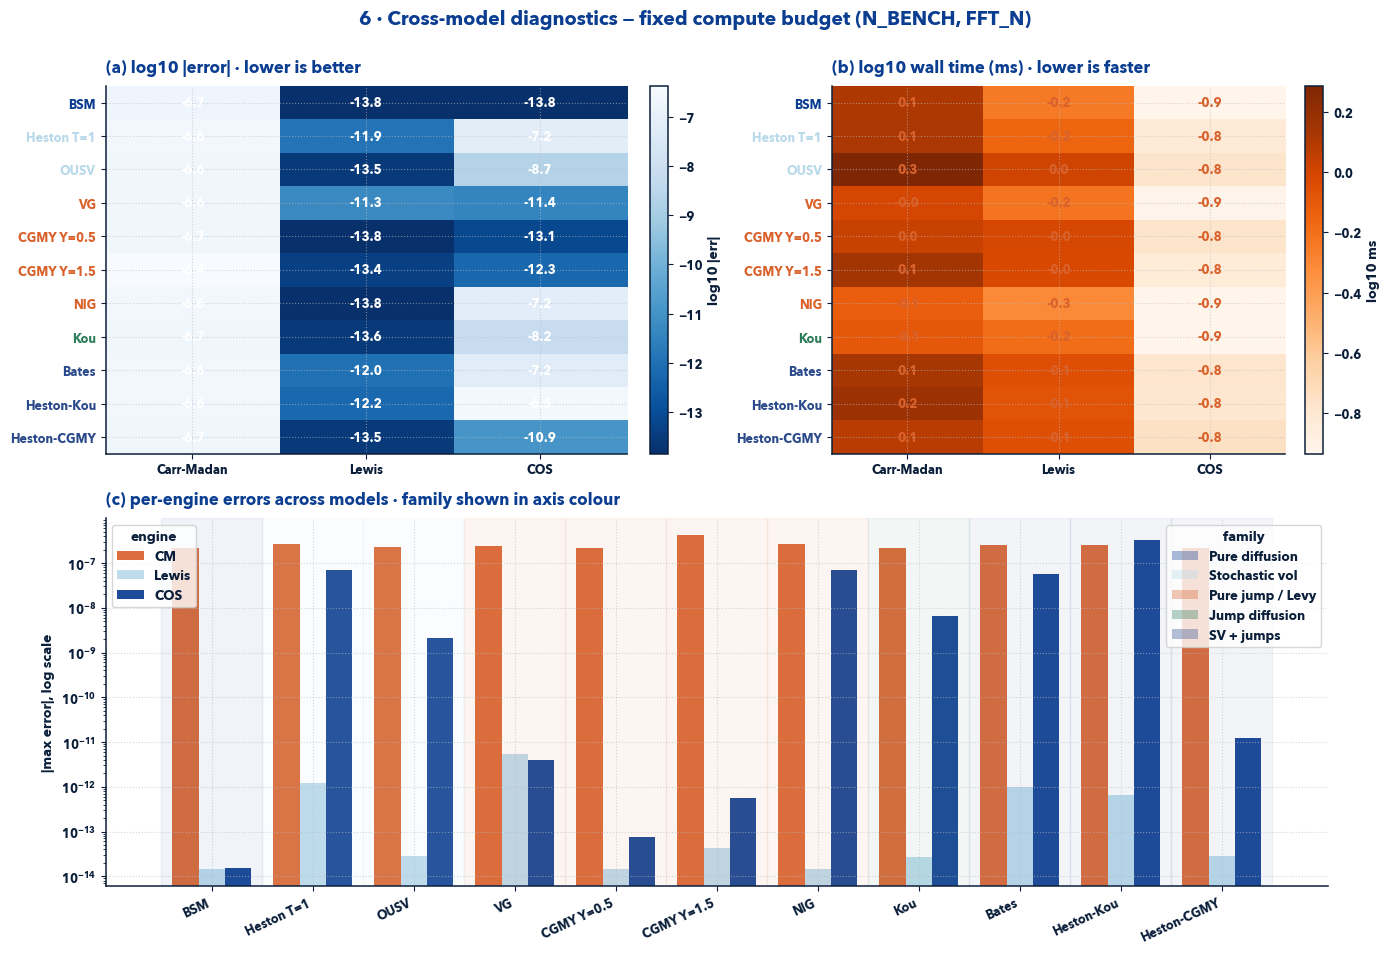

In [13]:
# Three-panel diagnostics figure: heatmap of errors, heatmap of timings, summary bar chart

fam_order = ["Pure diffusion", "Stochastic vol", "Pure jump / Levy",
             "Jump diffusion", "SV + jumps"]
fam_colors = {
    "Pure diffusion":   CU_BLUE,
    "Stochastic vol":   CU_LIGHT,
    "Pure jump / Levy": CU_ORANGE,
    "Jump diffusion":   CU_GREEN,
    "SV + jumps":       "#2b4a8b",
}

df6s = df6.sort_values(
    by="family",
    key=lambda s: s.map({f:i for i,f in enumerate(fam_order)})
).reset_index(drop=True)

err_mat = np.log10(np.clip(df6s[["err_CM","err_Lewis","err_COS"]].values.astype(float), 1e-16, None))
ms_mat  = np.log10(np.clip(df6s[["ms_CM","ms_Lewis","ms_COS"]].values.astype(float),  1e-3,  None))

fig = plt.figure(figsize=(14, 9.5))
gs  = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1.15, 1])

# Panel (a): error heatmap
ax0 = fig.add_subplot(gs[0, 0])
im0 = ax0.imshow(err_mat, aspect="auto", cmap="Blues_r")
ax0.set_xticks(range(3)); ax0.set_xticklabels(["Carr-Madan","Lewis","COS"])
ax0.set_yticks(range(len(df6s))); ax0.set_yticklabels(df6s["model"])
for i in range(err_mat.shape[0]):
    for j in range(err_mat.shape[1]):
        v = err_mat[i,j]
        ax0.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9.2,
                 color="white" if v < -6 else CU_BLUE)
# family-colour row labels
for i, fam in enumerate(df6s["family"]):
    ax0.get_yticklabels()[i].set_color(fam_colors.get(fam, CU_BLUE))
    ax0.get_yticklabels()[i].set_fontweight("bold")
ax0.set_title("(a) log10 |error| · lower is better")
plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04, label="log10 |err|")

# Panel (b): runtime heatmap
ax1 = fig.add_subplot(gs[0, 1])
im1 = ax1.imshow(ms_mat, aspect="auto", cmap="Oranges")
ax1.set_xticks(range(3)); ax1.set_xticklabels(["Carr-Madan","Lewis","COS"])
ax1.set_yticks(range(len(df6s))); ax1.set_yticklabels(df6s["model"])
for i in range(ms_mat.shape[0]):
    for j in range(ms_mat.shape[1]):
        v = ms_mat[i,j]
        ax1.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9.2,
                 color="white" if v > 0.6 else CU_ORANGE)
for i, fam in enumerate(df6s["family"]):
    ax1.get_yticklabels()[i].set_color(fam_colors.get(fam, CU_BLUE))
    ax1.get_yticklabels()[i].set_fontweight("bold")
ax1.set_title("(b) log10 wall time (ms) · lower is faster")
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label="log10 ms")

# Panel (c): error bar chart, family-coloured, with anomaly badges
ax2 = fig.add_subplot(gs[1, :])
x = np.arange(len(df6s))
w = 0.26
for i, (eng, col) in enumerate([("err_CM", CU_ORANGE),
                                 ("err_Lewis", CU_LIGHT),
                                 ("err_COS", CU_BLUE)]):
    ys = np.clip(df6s[eng].values.astype(float), 1e-16, None)
    ax2.bar(x + (i-1)*w, ys, w, label=eng.replace("err_",""), color=col, alpha=0.92)

# family bands along x
for i, row in df6s.iterrows():
    ax2.axvspan(i - 0.5, i + 0.5,
                color=fam_colors.get(row["family"], CU_BLUE), alpha=0.06)
# anomaly flag
for i, row in df6s.iterrows():
    if row["status"] == "anomaly":
        ymax = np.nanmax([row["err_CM"], row["err_Lewis"], row["err_COS"]])
        ax2.text(i, ymax*1.8, "anomaly", ha="center", fontsize=10, fontweight="bold",
                 color="white",
                 bbox=dict(facecolor=CU_ORANGE, edgecolor="none", boxstyle="round,pad=0.3"))
ax2.set_yscale("log")
ax2.set_xticks(x); ax2.set_xticklabels(df6s["model"], rotation=25, ha="right")
ax2.set_ylabel("|max error|, log scale")
ax2.set_title("(c) per-engine errors across models · family shown in axis colour")

# dual legend: engines + families
eng_leg = ax2.legend(title="engine", loc="upper left", fontsize=9.5)
ax2.add_artist(eng_leg)
fam_handles = [Patch(facecolor=fam_colors[f], alpha=0.35, label=f) for f in fam_order]
ax2.legend(handles=fam_handles, title="family", loc="upper right", fontsize=9.5)

plt.suptitle("6 · Cross-model diagnostics — fixed compute budget (N_BENCH, FFT_N)",
             color=CU_BLUE, fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

## 7. Conclusions

What the notebook establishes:

1. **Shared benchmark:** one contract and one truth value make the comparisons interpretable.
2. **MC vs Carr-Madan:** Monte Carlo remains a useful validator, but not the right primary method for European strips when a characteristic function is available.
3. **Carr-Madan vs Lewis:** both methods work well inside a stable parameter region; sensitivity is numerical, not conceptual.
4. **Plain COS:** spectral convergence is very strong on smooth densities.
5. **Improved truncation:** the gain comes from better support selection, not from changing the COS pricing formula.
6. **Cross-model diagnostics:** performance differences are often family-specific rather than model-specific.

Follow-up items:

1. Investigate the anomaly rows from Section 6 in the library code, not in the notebook presentation layer.
2. Consider promoting the adaptive support-selection policy to the default path when the classical width becomes too large.
3. Compare Lewis `quad` vs `trapz` on the heavier-tail rows.